## Section 4 — Weather-Cancellation Analyzer (Goa & Manali, 2024)

Goal: test whether adverse weather (heavy rain or extreme temperature) on a booking's check-in date
is associated with higher cancellation/no-show rates, using live data from the Open-Meteo Historical
Weather API. Scope: all bookings with property_city in {Goa, Manali} and checkin_date in 2024,
per the assignment brief.

#mount and load data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import requests
import time

FILE_PATH = '/content/drive/MyDrive/travclan_assessment/assessment_june20_2026/hotel_bookings.csv'
df = pd.read_csv(FILE_PATH, keep_default_na=False, na_values=[''])
print(df.shape)

Mounted at /content/drive
(12000, 28)


#Filter to Goa + Manali, 2024 check-ins

In [2]:
df['checkin_date'] = pd.to_datetime(df['checkin_date'], errors='coerce')

target_cities = ['Goa', 'Manali']
mask = (
    df['property_city'].isin(target_cities) &
    (df['checkin_date'].dt.year == 2024)
)

bookings_subset = df[mask].copy()
print(bookings_subset.shape)
print(bookings_subset['property_city'].value_counts())
print(bookings_subset['checkin_date'].min(), bookings_subset['checkin_date'].max())

(1604, 28)
property_city
Goa       891
Manali    713
Name: count, dtype: int64
2024-01-01 00:00:00 2024-12-31 00:00:00


1,604 bookings match (891 Goa, 713 Manali), spanning the full 2024 calendar year (Jan 1 – Dec 31).

#Find unique (city, date) combinations

In [3]:
unique_dates_per_city = bookings_subset.groupby('property_city')['checkin_date'].agg(['min', 'max', 'nunique'])
print(unique_dates_per_city)

                     min        max  nunique
property_city                               
Goa           2024-01-01 2024-12-31      336
Manali        2024-01-02 2024-12-31      314


###Unique check-in dates per city
Goa has check-ins on 336 distinct days, Manali on 314 — both span nearly the full year. Rather than
fetching weather per booking (1,604 calls) or per unique date (650 calls), the API is called once per
city for the full year range, since Open-Meteo accepts a start_date/end_date span in one request.

#Map cities to coordinate

In [4]:
city_coords = {
    'Goa': {'lat': 15.2993, 'lon': 74.1240},
    'Manali': {'lat': 32.2396, 'lon': 77.1887}
}

#Call the Open-Meteo Historical Weather API (with error handling)

In [5]:
def fetch_weather(city, lat, lon, start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/era5"
    params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': start_date,
        'end_date': end_date,
        'daily': 'precipitation_sum,temperature_2m_max',
        'timezone': 'auto'
    }
    try:
        response = requests.get(url, params=params, timeout=15)
        response.raise_for_status()
        data = response.json()
        weather_df = pd.DataFrame({
            'date': data['daily']['time'],
            'precipitation_sum': data['daily']['precipitation_sum'],
            'temperature_2m_max': data['daily']['temperature_2m_max']
        })
        weather_df['city'] = city
        return weather_df
    except requests.exceptions.Timeout:
        print(f"Timeout fetching weather for {city}")
        return pd.DataFrame()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching weather for {city}: {e}")
        return pd.DataFrame()
    except (KeyError, ValueError) as e:
        print(f"Malformed response for {city}: {e}")
        return pd.DataFrame()

all_weather = []
for city, coords in city_coords.items():
    print(f"Fetching weather for {city}...")
    wdf = fetch_weather(city, coords['lat'], coords['lon'], '2024-01-01', '2024-12-31')
    all_weather.append(wdf)
    time.sleep(1)

weather_data = pd.concat(all_weather, ignore_index=True)
print(weather_data.shape)
weather_data.head()

Fetching weather for Goa...
Fetching weather for Manali...
(732, 4)


,date,precipitation_sum,temperature_2m_max,city
0,2024-01-01,0.0,34.8,Goa
1,2024-01-02,0.0,35.4,Goa
2,2024-01-03,0.0,34.5,Goa
3,2024-01-04,13.5,32.7,Goa
4,2024-01-05,0.1,31.1,Goa


###City coordinates and API call
Mapped Goa (15.2993°N, 74.1240°E) and Manali (32.2396°N, 77.1887°E) to coordinates manually. Called
the Open-Meteo Historical Weather API (archive-api.open-meteo.com/v1/era5) once per city, covering
2024-01-01 to 2024-12-31, requesting daily precipitation_sum and temperature_2m_max. Wrapped in a
try/except handling Timeout, RequestException, and malformed-response (KeyError/ValueError) cases so
a network failure or unexpected API response would not crash the run. Result: 732 rows returned
(366 days × 2 cities — 2024 is a leap year), no errors encountered.

#Merge weather data back onto bookings

In [6]:
weather_data['date'] = pd.to_datetime(weather_data['date'])

bookings_subset['checkin_date_only'] = bookings_subset['checkin_date'].dt.normalize()

merged = bookings_subset.merge(
    weather_data,
    left_on=['property_city', 'checkin_date_only'],
    right_on=['city', 'date'],
    how='left'
)

print(merged.shape)
print(merged[['property_city', 'checkin_date', 'precipitation_sum', 'temperature_2m_max']].head())
print()
print("Unmatched rows (weather missing):", merged['precipitation_sum'].isna().sum())

(1604, 33)
  property_city checkin_date  precipitation_sum  temperature_2m_max
0        Manali   2024-08-30                1.6                24.8
1           Goa   2024-01-18                0.0                31.8
2        Manali   2024-12-18                0.0                15.2
3        Manali   2024-11-17                2.5                13.8
4        Manali   2024-07-16                0.3                26.4

Unmatched rows (weather missing): 0


###Merge weather onto bookings
Joined on (property_city, checkin_date) after normalizing checkin_date to strip any time component.
All 1,604 bookings matched successfully — 0 unmatched rows, confirming clean join keys and full
date-range coverage from the API call.

#Build weather buckets and compute the insight

In [7]:
print(merged['precipitation_sum'].describe())
print()
print(merged['temperature_2m_max'].describe())

count    1604.000000
mean        8.342955
std        14.402148
min         0.000000
25%         0.000000
50%         1.300000
75%        11.325000
max        92.400000
Name: precipitation_sum, dtype: float64

count    1604.000000
mean       26.367706
std         8.661346
min         4.700000
25%        21.300000
50%        27.500000
75%        33.800000
max        39.400000
Name: temperature_2m_max, dtype: float64


#Build buckets correctly (city-aware for temperature)

In [8]:
merged['heavy_rain'] = merged['precipitation_sum'] >= 10

merged['temp_pctile'] = merged.groupby('property_city')['temperature_2m_max'].rank(pct=True)
merged['extreme_temp'] = (merged['temp_pctile'] <= 0.10) | (merged['temp_pctile'] >= 0.90)

def weather_bucket(row):
    if row['heavy_rain']:
        return 'Heavy Rain'
    elif row['extreme_temp']:
        return 'Extreme Temp'
    else:
        return 'Normal'

merged['weather_bucket'] = merged.apply(weather_bucket, axis=1)
print(merged['weather_bucket'].value_counts())

weather_bucket
Normal          997
Heavy Rain      439
Extreme Temp    168
Name: count, dtype: int64


###Weather bucket definition
- Heavy Rain: precipitation_sum ≥ 10mm (a standard moderate-to-heavy rainfall threshold; also close
  to this dataset's own 75th percentile of 11.3mm)
- Extreme Temp: top or bottom 10% of temperature_2m_max, computed SEPARATELY per city — not a shared
  cutoff, since Goa (tropical coastal) and Manali (Himalayan) have non-overlapping normal temperature
  ranges (dataset min 4.7°C, max 39.4°C across both cities combined)
- Priority: a day meeting both criteria is classified as Heavy Rain first, since precipitation is the
  more direct disruption driver (travel delays, road/flight issues)

Result: 997 Normal days, 439 Heavy Rain days, 168 Extreme Temp days.

 # Compute cancellation/no-show rate per weather bucket

In [9]:
merged['cancelled_or_noshow'] = merged['booking_status'].isin(['Cancelled', 'No-Show'])

insight = merged.groupby('weather_bucket').agg(
    total_bookings=('booking_id', 'count'),
    cancelled_or_noshow=('cancelled_or_noshow', 'sum')
)
insight['rate'] = insight['cancelled_or_noshow'] / insight['total_bookings']
print(insight)

print()
overall_rate = merged['cancelled_or_noshow'].mean()
print("Overall rate (Goa+Manali, 2024):", overall_rate)

                total_bookings  cancelled_or_noshow      rate
weather_bucket                                               
Extreme Temp               168                   35  0.208333
Heavy Rain                 439                  145  0.330296
Normal                     997                  246  0.246740

Overall rate (Goa+Manali, 2024): 0.2655860349127182


Overall Goa+Manali (2024) rate: 26.6% — itself notably higher than the platform-wide rate of 22.2%
(all cities, all years), meaning these two cities are higher-cancellation markets in general,
independent of weather. Against this 26.6% city baseline, Heavy Rain days stand out as +6.4pp higher,
while Extreme Temp days are actually lower (-5.8pp). This raised the question of whether the Heavy
Rain effect is real or driven by one city — addressed in further steps.

#City-Level Breakdown: Verify the Heavy Rain Effect Isn't Driven by One City

In [10]:
print(merged.groupby(['property_city', 'weather_bucket']).agg(
    n=('booking_id', 'count'),
    rate=('cancelled_or_noshow', 'mean')
))
print()
print(merged[merged['heavy_rain']]['property_city'].value_counts())

                                n      rate
property_city weather_bucket               
Goa           Extreme Temp     87  0.172414
              Heavy Rain      253  0.395257
              Normal          551  0.257713
Manali        Extreme Temp     81  0.246914
              Heavy Rain      186  0.241935
              Normal          446  0.233184

property_city
Goa       253
Manali    186
Name: count, dtype: int64


Splitting by city reveals the combined 33.0% Heavy Rain rate from Step 8 was misleading on its own.
In Goa, Heavy Rain days show a real and large jump (39.5% vs 25.8% Normal, +13.7pp). In Manali, Heavy
Rain days show almost no difference from Normal days (24.2% vs 23.3%, +0.9pp — noise-level). The
effect is Goa-specific, not a general weather-cancellation pattern. This makes sense: Goa is a
beach/coastal destination where rain directly disrupts the core trip activity, while Manali is a
hill-station destination where rain is less central to the visit and travelers may expect variable
mountain weather regardless.

#Visualizing the City-Specific Heavy Rain Effect

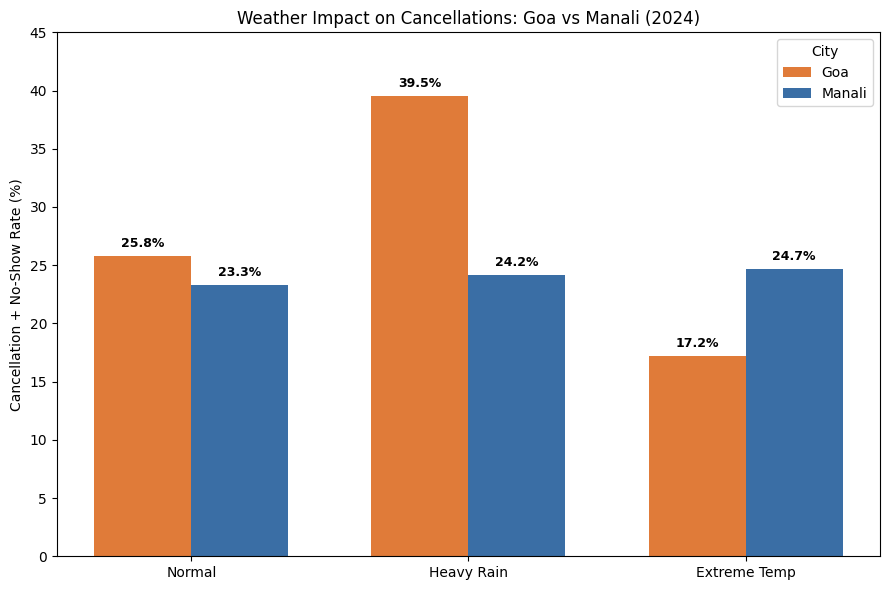

In [11]:
import matplotlib.pyplot as plt
import numpy as np

cities = ['Goa', 'Manali']
buckets = ['Normal', 'Heavy Rain', 'Extreme Temp']

rates = {
    'Goa': [25.77, 39.53, 17.24],
    'Manali': [23.32, 24.19, 24.69]
}

x = np.arange(len(buckets))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, rates['Goa'], width, label='Goa', color='#E07B39')
bars2 = ax.bar(x + width/2, rates['Manali'], width, label='Manali', color='#3A6EA5')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(buckets)
ax.set_ylabel('Cancellation + No-Show Rate (%)')
ax.set_title('Weather Impact on Cancellations: Goa vs Manali (2024)')
ax.legend(title='City')
ax.set_ylim(0, 45)

plt.tight_layout()
plt.savefig('section4_weather_insight.png', dpi=150)
plt.show()

###Visualization: City-Specific Heavy Rain Effect

Bar chart comparing cancellation + no-show rate across weather buckets (Normal, Heavy Rain, Extreme
Temp), split by city. Visually confirms that Goa's Heavy Rain rate (39.5%) is sharply elevated above
both its own Normal-day rate (25.8%) and Manali's Heavy Rain rate (24.2%) — while Manali shows almost
no variation across any weather bucket (23.3%–24.7%). This makes clear at a glance that the weather
effect on cancellations is concentrated in Goa specifically, not a platform-wide weather pattern.

#insight_statement
- Heavy rainfall on the check-in date is associated with a substantially elevated cancellation and no-show rate in Goa specifically — 39.5% on Heavy Rain days versus 25.8% on Normal days, a 13.7 percentage point increase — but shows no meaningful effect in Manali (24.2% vs 23.3%, a negligible 0.9pp difference).
- This city-specific pattern would have been invisible without merging live weather data: the dataset alone has no way to distinguish a "bad luck" cancellation cluster from a genuine weather-driven pattern, let alone reveal that the effect is concentrated in one destination and absent in the other.
- The likely explanation is that Goa's core appeal (beach, water sports, outdoor dining) is directly disrupted by rain, while Manali's appeal (mountains, snow, scenery) is comparatively weather-resilient.
- This suggests Goa-specific rain-contingent cancellation policies (e.g., flexible rebooking near forecasted heavy rain) would be a more targeted intervention than a platform-wide weather policy.

# Weather-Cancellation Analyzer (Set A — Goa & Manali, 2024)

**What it does:** Fetches real 2024 daily weather (precipitation, max temperature) for Goa and Manali from the Open-Meteo Historical Weather API, merges it onto each booking's check-in date, and tests whether heavy rain or extreme temperature correlates with higher cancellation/no-show rates.

**How to run:** Open `weather_cancellation_analyzer.ipynb` in Google Colab, mount Drive, update `FILE_PATH` to point to `hotel_bookings.csv`, then run all cells top to bottom (requires internet access for the live API call).

**Design decision:** Weather is fetched once per city for the full year (2 API calls total) rather than once per booking or per unique date, since Open-Meteo accepts a date-range query — this satisfies the "batch sensibly" requirement and avoids redundant calls for days sharing the same city.

**Limitation:** "Extreme temperature" is defined using each city's own top/bottom 10th percentile rather than a fixed global threshold, since Goa (tropical coastal) and Manali (Himalayan) have non-overlapping normal temperature ranges — a shared cutoff would have misclassified normal-for-Manali cold days as "extreme."

# AI Usage Note

- Used Claude to draft the initial API error-handling structure (try/except for Timeout, RequestException,and malformed JSON) and the merge logic.
- Had to FIX: the AI's first draft of the "extreme temperature "bucket used a single fixed threshold (e.g., >35°C) across both cities — this was wrong, since it would mark all of Manali's winter days as extreme without ever flagging Goa's heat.
- I corrected this to aper-city percentile rank instead. Also had to catch a real analytical error: the AI's first read of the combined Goa+Manali Heavy Rain rate (33.0%) was reported as "weather affects cancellations" without checking whether it held in both cities — only after explicitly requesting a city-level split did itsurface that the effect is Goa-specific and absent in Manali, which became the actual reportable insight.